In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [2]:
df= pd.read_csv("../data/loan_data_features.csv")

In [3]:
print(f"{df.shape[0]}- rows {df.shape[1]}- columns")

120262- rows 22- columns


In [4]:
print(df['SeriousDlqin2yrs'].value_counts())
print(df["SeriousDlqin2yrs"].value_counts(normalize=True).mul(100).round(2))


SeriousDlqin2yrs
0    111906
1      8356
Name: count, dtype: int64
SeriousDlqin2yrs
0    93.05
1     6.95
Name: proportion, dtype: float64


In [5]:
x=df.drop(columns=['SeriousDlqin2yrs'])
y=df["SeriousDlqin2yrs"]
for col in x.columns:
    print(f" - {col}")

 - RevolvingUtilizationOfUnsecuredLines
 - age
 - NumberOfTime30-59DaysPastDueNotWorse
 - DebtRatio
 - MonthlyIncome
 - NumberOfOpenCreditLinesAndLoans
 - NumberOfTimes90DaysLate
 - NumberRealEstateLoansOrLines
 - NumberOfTime60-89DaysPastDueNotWorse
 - NumberOfDependents
 - MonthlyDebt
 - IncomePerDependent
 - TotalTimesLate
 - HighRiskFlag
 - AgeGroup_Young
 - AgeGroup_Middle
 - AgeGroup_Senior
 - AgeGroup_Elderly
 - CreditUtilCategory_Medium
 - CreditUtilCategory_High
 - CreditUtilCategory_Very High


In [6]:
x_train, x_test, y_train, y_test=train_test_split(x,y, stratify=y, random_state=42, test_size=0.2)

In [7]:
print(x_test.shape)
print(x_train.shape)
print(y_test.value_counts())
print(y_train.value_counts())

(24053, 21)
(96209, 21)
SeriousDlqin2yrs
0    22382
1     1671
Name: count, dtype: int64
SeriousDlqin2yrs
0    89524
1     6685
Name: count, dtype: int64


In [8]:
print(x_train.isna().sum()[x_train.isna().sum() > 0])

IncomePerDependent    866
dtype: int64


In [9]:
for col in x_train.columns:
    if x_train[col].isna().sum()>0:
        x_median=x_train[col].median()
        x_train[col]=x_train[col].fillna(x_median)
        x_test[col]=x_test[col].fillna(x_median)
print(x_train.isnull().sum().sum())

0


In [10]:
print(np.isinf(x_train).sum().sum())

52297


In [12]:
x_train = x_train.replace([np.inf, -np.inf], np.nan)
x_test = x_test.replace([np.inf, -np.inf], np.nan)

In [15]:
nan_cols = x_train.columns[x_train.isna().any()]
print(x_train[nan_cols].isna().sum())

IncomePerDependent    52297
dtype: int64


In [16]:
x_train = x_train.fillna(x_train.median())
x_test = x_test.fillna(x_train.median())

In [18]:
print("Total NaN values:", x_train.isna().sum().sum())

Total NaN values: 0


In [19]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)
print(f"\nTraining set BEFORE SMOTE: {x_train.shape[0]:,} rows")
print(f"Training set AFTER SMOTE : {X_train_resampled.shape[0]:,} rows")
print(f"\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("\nPercentage after SMOTE:")
print(pd.Series(y_train_resampled).value_counts(normalize=True).mul(100).round(2))


Training set BEFORE SMOTE: 96,209 rows
Training set AFTER SMOTE : 179,048 rows

Class distribution AFTER SMOTE:
SeriousDlqin2yrs
0    89524
1    89524
Name: count, dtype: int64

Percentage after SMOTE:
SeriousDlqin2yrs
0    50.0
1    50.0
Name: proportion, dtype: float64


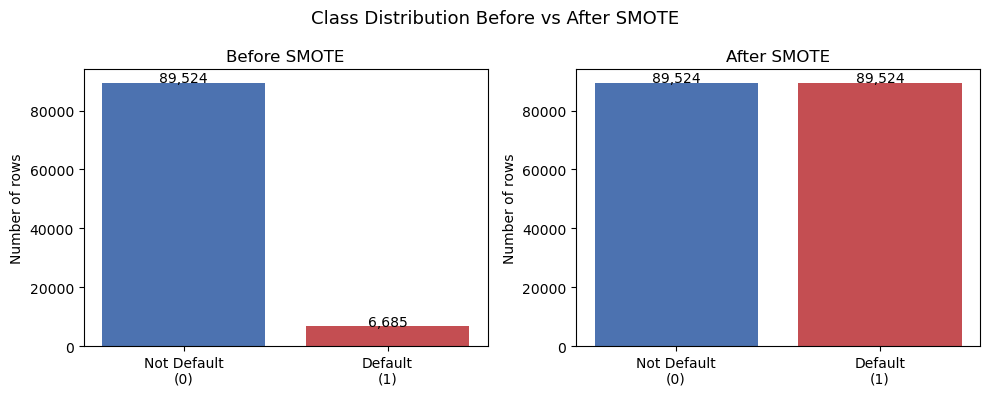

Chart saved!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
axes[0].bar(
    ["Not Default\n(0)", "Default\n(1)"],
    y_train.value_counts().sort_index().values,
    color=["#4C72B0", "#C44E52"]
)
axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Number of rows")
for i, v in enumerate(y_train.value_counts().sort_index().values):
    axes[0].text(i, v + 100, f"{v:,}", ha='center', fontsize=10)

# After SMOTE
axes[1].bar(
    ["Not Default\n(0)", "Default\n(1)"],
    pd.Series(y_train_resampled).value_counts().sort_index().values,
    color=["#4C72B0", "#C44E52"]
)
axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Number of rows")
for i, v in enumerate(pd.Series(y_train_resampled).value_counts().sort_index().values):
    axes[1].text(i, v + 100, f"{v:,}", ha='center', fontsize=10)

plt.suptitle("Class Distribution Before vs After SMOTE", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/day5_smote_comparison.png")
plt.show()
print("Chart saved!")

In [24]:
import os
os.makedirs("../data", exist_ok=True)

# Save all 4 splits for model training tomorrow
X_train_resampled.to_csv("../data/X_train.csv", index=False)
x_test.to_csv("../data/X_test.csv", index=False)
pd.Series(y_train_resampled).to_csv("../data/y_train.csv", index=False)
pd.Series(y_test).to_csv("../data/y_test.csv", index=False)

print("Saved all 4 files:")
print("  data/X_train.csv   SMOTE applied training features")
print("  data/X_test.csv    original test features")
print("  data/y_train.csv   SMOTE applied training labels")
print("  data/y_test.csv    original test labels")
print("\nDay 5 complete!")

Saved all 4 files:
  data/X_train.csv   SMOTE applied training features
  data/X_test.csv    original test features
  data/y_train.csv   SMOTE applied training labels
  data/y_test.csv    original test labels

Day 5 complete!
